In [3]:
import sys
sys.path.append("../../src")

from models import PINN
from utils import derivative, get_device
import torch
import torch.nn as nn

In [4]:
# setting gpu
device = get_device()
print(device)

cuda


# setting the model

In [5]:
model = PINN(input_dim=3, hidden_dim=64, output_dim=2, num_layers=4).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# 2D burgers Equation

$$
\frac{\partial u}{\partial t}
+ u \frac{\partial u}{\partial x}
+ v \frac{\partial u}{\partial y}
=
\nu \left(
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
\right)
$$

$$
\frac{\partial v}{\partial t}
+ u \frac{\partial v}{\partial x}
+ v \frac{\partial v}{\partial y}
=
\nu \left(
\frac{\partial^2 v}{\partial x^2}
+
\frac{\partial^2 v}{\partial y^2}
\right)
$$

## initial condition
$$
u(x,y,0) = -\sin(\pi x)\cos(\pi y), \quad
v(x,y,0) = \cos(\pi x)\sin(\pi y)
$$

In [6]:
x_ic = torch.linspace(-1, 1, 100, device=device)
y_ic = torch.linspace(-1, 1, 100, device=device)

X_ic, Y_ic = torch.meshgrid(x_ic, y_ic, indexing="ij")

x_ic = X_ic.reshape(-1,1)
y_ic = Y_ic.reshape(-1,1)
t_ic = torch.zeros_like(x_ic)

u_ic_true = torch.exp(-20 * ((x_ic + 0.4)**2 + y_ic**2)) - torch.exp(-20 * ((x_ic - 0.4)**2 + y_ic**2))
v_ic_true = torch.zeros_like(u_ic_true)

## boundary conditions
$$
u(x,y,t) = 0, \quad v(x,y,t) = 0 \quad \text{on } \partial \Omega
$$


In [7]:
Nb = 1000

t_b = torch.rand(Nb, 1, device=device)

#left (x = -1)
y_bl = 2 * torch.rand(Nb, 1, device=device) - 1
x_bl = -torch.ones_like(t_b)

# rigth (x = 1)
y_br = 2 * torch.rand(Nb, 1, device=device) - 1
x_br = torch.ones_like(t_b)

# bottom (y = -1)
x_bb = 2 * torch.rand(Nb, 1, device=device) - 1
y_bb = -torch.ones_like(t_b)

# top (y = 1)
x_bt = 2 * torch.rand(Nb, 1, device=device) - 1
y_bt = torch.ones_like(t_b)

# targets 
u_bc = torch.zeros(Nb, 1, device=device)
v_bc = torch.zeros(Nb, 1, device=device)

## domain
$$
(x,y,t) \in [-1,1]^2 \times [0,1]
$$

In [8]:
Nf = 10000

t_f = torch.rand(Nf, 1, device=device).requires_grad_(True)

x_f = 2 * torch.rand(Nf, 1, device=device) - 1
x_f.requires_grad_(True)

y_f = 2 * torch.rand(Nf, 1, device=device) - 1
y_f.requires_grad_(True)

tensor([[-0.1808],
        [-0.3816],
        [-0.6691],
        ...,
        [-0.7251],
        [-0.7877],
        [-0.1433]], device='cuda:0', requires_grad=True)

In [9]:

def pde_residual(model, t, x, y, nu):
    uv = model(t, x, y)
    u = uv[:, 0:1]
    v = uv[:, 1:2]

    u_t = derivative(u, t)
    u_x = derivative(u, x)
    u_y = derivative(u, y)

    v_t = derivative(v, t)
    v_x = derivative(v, x)
    v_y = derivative(v, y)

    u_xx = derivative(u_x, x)
    u_yy = derivative(u_y, y)

    v_xx = derivative(v_x, x)
    v_yy = derivative(v_y, y)

    r_u = u_t + u*u_x + v*u_y - nu*(u_xx + u_yy)
    r_v = v_t + u*v_x + v*v_y - nu*(v_xx + v_yy)

    return r_u, r_v

In [10]:
epochs = 10000
nu = 0.01
for epoch in range(epochs):
    optimizer.zero_grad()

    r_u, r_v = pde_residual(model, t_f, x_f, y_f, nu)
    loss_pde = torch.mean(r_u**2) + torch.mean(r_v**2)

    uv_ic = model(t_ic, x_ic, y_ic)
    u_ic = uv_ic[:, 0:1]
    v_ic = uv_ic[:, 1:2]

    loss_ic = torch.mean((u_ic - u_ic_true)**2) + torch.mean((v_ic - v_ic_true)**2)

    uv_bc_l = model(t_b, x_bl, y_bl)
    uv_bc_r = model(t_b, x_br, y_br)
    uv_bc_b = model(t_b, x_bb, y_bb)
    uv_bc_t = model(t_b, x_bt, y_bt)

    loss_bc = (
        torch.mean(uv_bc_l**2) +
        torch.mean(uv_bc_r**2) +
        torch.mean(uv_bc_b**2) +
        torch.mean(uv_bc_t**2)
    )

    loss = loss_pde + loss_ic + loss_bc

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"epoch {epoch} | "f"total loss: {loss} | "f"loss pde: {loss_pde} | " f"ic pde: {loss_ic} | "  f"bc pde: {loss_bc}")

epoch 0 | total loss: 0.07764499634504318 | loss pde: 0.0006011617369949818 | ic pde: 0.054240744560956955 | bc pde: 0.022803090512752533
epoch 1000 | total loss: 0.010878478176891804 | loss pde: 0.0026564428117126226 | ic pde: 0.008113675750792027 | bc pde: 0.00010835953435162082
epoch 2000 | total loss: 0.00555264251306653 | loss pde: 0.002024610061198473 | ic pde: 0.0033967383205890656 | bc pde: 0.00013129398575983942
epoch 3000 | total loss: 0.0020688152872025967 | loss pde: 0.0008211633539758623 | ic pde: 0.001170082250609994 | bc pde: 7.756965351291001e-05
epoch 4000 | total loss: 0.001278105890378356 | loss pde: 0.0006060778396204114 | ic pde: 0.0005338485934771597 | bc pde: 0.0001381793845212087
epoch 5000 | total loss: 0.0005181728629395366 | loss pde: 0.0002925196895375848 | ic pde: 0.00020156217215117067 | bc pde: 2.4090968508971855e-05
epoch 6000 | total loss: 0.0003902932512573898 | loss pde: 0.00022794790857005864 | ic pde: 0.00013933425361756235 | bc pde: 2.3011103621684

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_vector_field(model, t_value=0.5, n=30):
    model.eval()

    device = next(model.parameters()).device

    x = torch.linspace(-1, 1, n, device=device)
    y = torch.linspace(-1, 1, n, device=device)

    X, Y = torch.meshgrid(x, y, indexing="ij")

    x_test = X.reshape(-1, 1)
    y_test = Y.reshape(-1, 1)
    t_test = torch.full_like(x_test, t_value)

    with torch.no_grad():
        uv = model(t_test, x_test, y_test)

    u = uv[:, 0].reshape(n, n).cpu().numpy()
    v = uv[:, 1].reshape(n, n).cpu().numpy()

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()

    speed = np.sqrt(u**2 + v**2)

    plt.figure(figsize=(8, 8))

    q = plt.quiver(
        X,
        Y,
        u,
        v,
        speed,
        cmap="jet"
    )

    plt.colorbar(q, label=r"$\sqrt{u^2+v^2}$")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Velocity Field at t = {t_value}")

    plt.axis("equal")
    plt.tight_layout()

    plt.show()

IndentationError: expected an indented block after function definition on line 5 (2397474204.py, line 6)

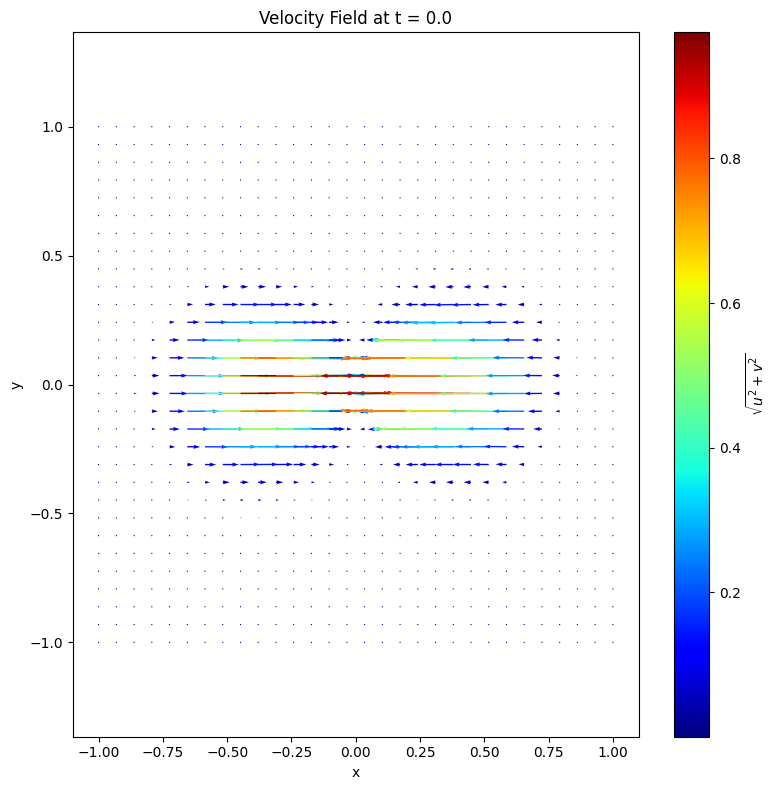

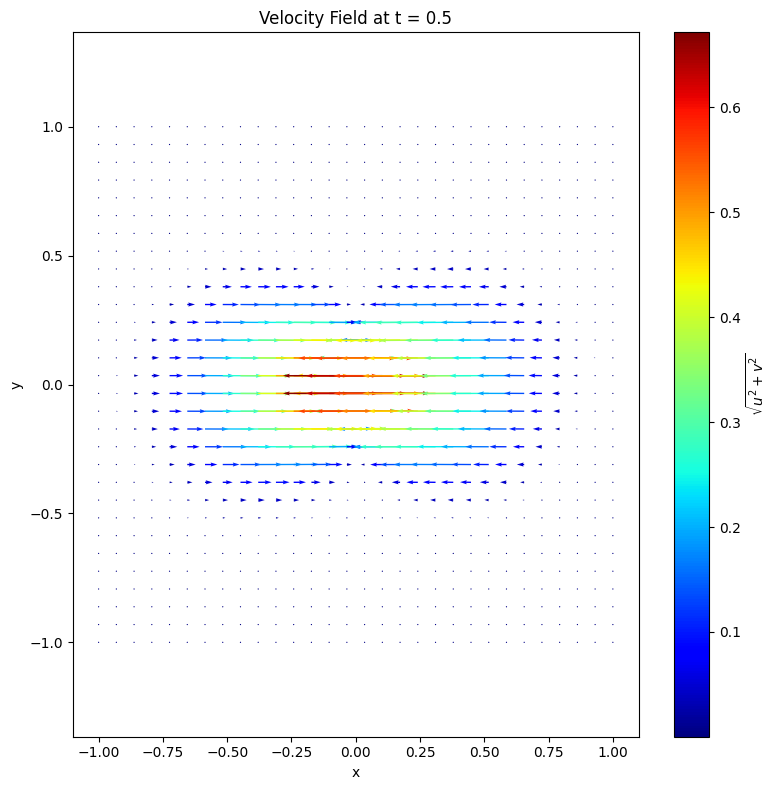

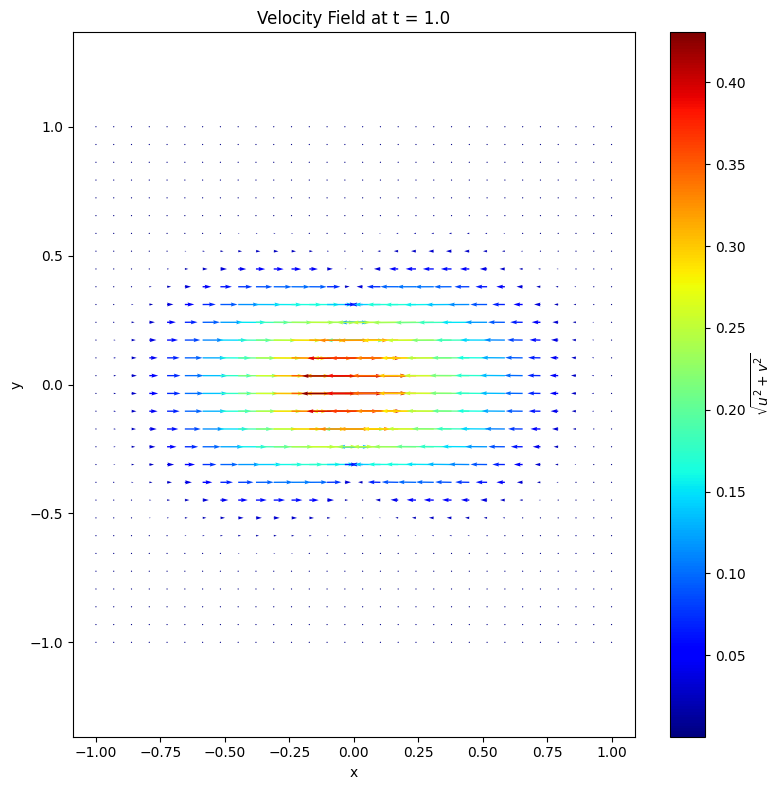

In [12]:
plot_vector_field(model, t_value=0.0)
plot_vector_field(model, t_value=0.5)
plot_vector_field(model, t_value=1.0)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_1d_slice(model, t_value=0.5, y_value=0.0, n=200, device=torch.device("cuda")):
    model.eval()
    
    x = torch.linspace(-1, 1, n, device=device).reshape(-1, 1)
    
    y = torch.full_like(x, y_value)
    t = torch.full_like(x, t_value)
    
    with torch.no_grad():
        uv = model(t, x, y)
        
    u = uv[:, 0].cpu().numpy()
    v = uv[:, 1].cpu().numpy()
    x_np = x.cpu().numpy()
    
    plt.figure(figsize=(8, 5))
    plt.plot(x_np, u, label='u (x-velocity)', color='blue', linewidth=2)
    plt.plot(x_np, v, label='v (y-velocity)', color='red', linestyle='--', linewidth=2)
    
    plt.title(f"1D Cross-Section at y={y_value}, t={t_value}")
    plt.xlabel("x")
    plt.ylabel("Velocity")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

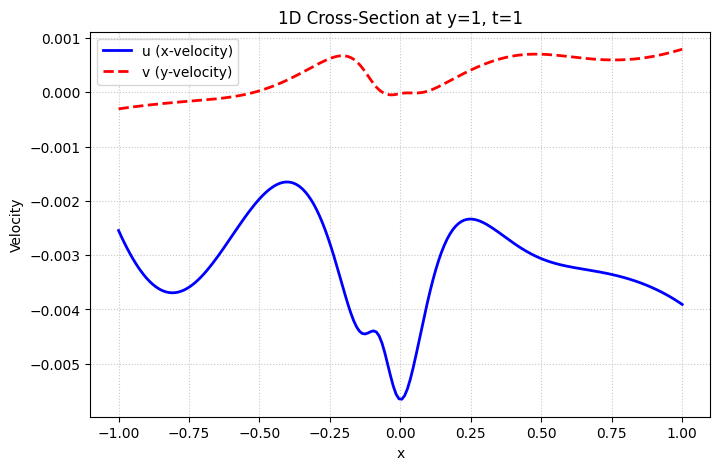

In [14]:
plot_1d_slice(model, 1, 1)

In [15]:
def plot_3d_surface(model, t_value=0.5, n=100, device=torch.device("cuda")):
    model.eval()
    
    x = torch.linspace(-1, 1, n, device=device)
    y = torch.linspace(-1, 1, n, device=device)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    
    x_test = X.reshape(-1, 1)
    y_test = Y.reshape(-1, 1)
    t_test = torch.full_like(x_test, t_value)
    
    with torch.no_grad():
        uv = model(t_test, x_test, y_test)

    u = uv[:, 0].reshape(n, n).cpu().numpy()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(
        X.cpu().numpy(), 
        Y.cpu().numpy(), 
        u,
        cmap='jet', 
        edgecolor='none'
    )
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='u velocity')
    ax.set_title(f"3D Surface of u(x,y) at t={t_value}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    
    plt.show()

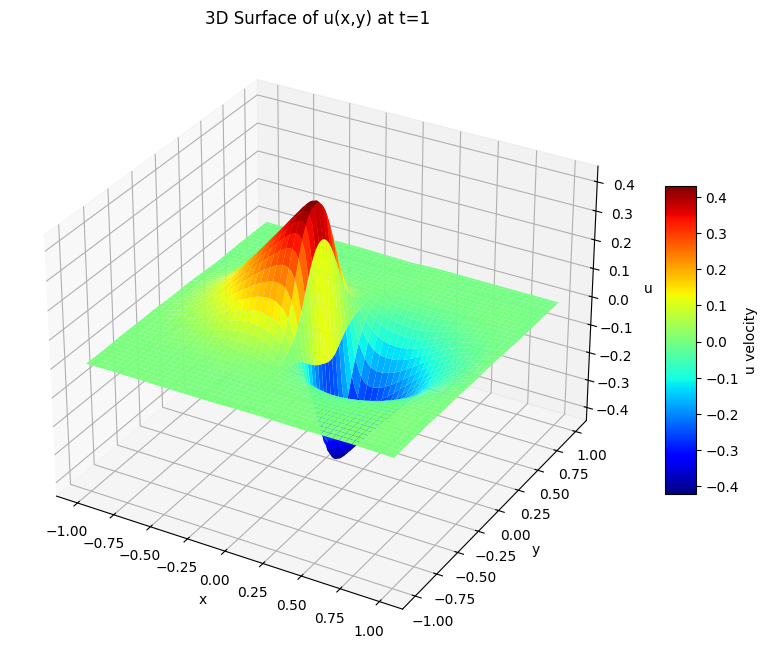

In [53]:
plot_3d_surface(model, 1)

In [17]:
def plot_streamlines(model, t_value=0.5, n=100, device=torch.device("cuda")):
    model.eval()
    
    x = torch.linspace(-1, 1, n, device=device)
    y = torch.linspace(-1, 1, n, device=device)
    
    X, Y = torch.meshgrid(x, y, indexing="ij")
    
    x_test = X.reshape(-1, 1)
    y_test = Y.reshape(-1, 1)
    t_test = torch.full_like(x_test, t_value)
    
    with torch.no_grad():
        uv = model(t_test, x_test, y_test)
        
    u = uv[:, 0].reshape(n, n).cpu().numpy()
    v = uv[:, 1].reshape(n, n).cpu().numpy()

    magnitude = np.sqrt(u**2 + v**2)
    
    plt.figure(figsize=(8, 8))
    
    strm = plt.streamplot(
        x.cpu().numpy(), 
        y.cpu().numpy(), 
        u.T,  
        v.T, 
        color=magnitude.T, 
        cmap='jet',
        density=1.5, 
        linewidth=1.5
    )
    
    plt.colorbar(strm.lines, label='Velocity Magnitude')
    plt.title(f"Fluid Streamlines at t={t_value}")
    plt.xlabel("x")
    plt.ylabel("y")
    
    plt.show()

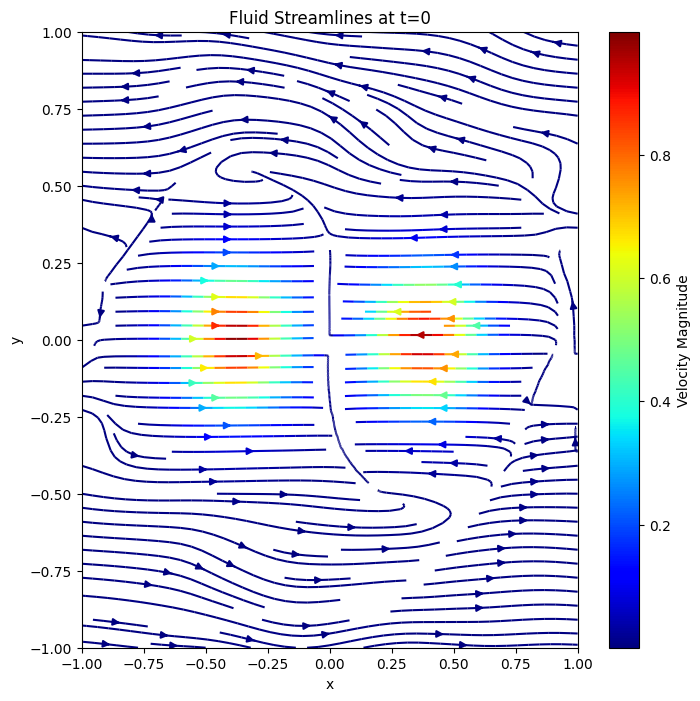

In [52]:
plot_streamlines(model, 0)

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_master_velocity(model, t_value=0.5, n=100, device=torch.device("cuda")):
    model.eval()

    x = torch.linspace(-1, 1, n, device=device)
    y = torch.linspace(-1, 1, n, device=device)
    X, Y = torch.meshgrid(x, y, indexing="ij")

    x_test = X.reshape(-1, 1)
    y_test = Y.reshape(-1, 1)
    t_test = torch.full_like(x_test, t_value)

    with torch.no_grad():
        uv = model(t_test, x_test, y_test)

    u = uv[:, 0].reshape(n, n).cpu().numpy()
    v = uv[:, 1].reshape(n, n).cpu().numpy()

    magnitude = np.sqrt(u**2 + v**2)

    max_magnitude = np.max(magnitude)

    fig, ax = plt.subplots(figsize=(10, 8))

    heatmap = ax.contourf(
        X.cpu().numpy(),
        Y.cpu().numpy(),
        magnitude,
        levels=1000,
        cmap='jet'
    )
    fig.colorbar(heatmap, ax=ax, label=r"$\sqrt{u^2+v^2}$")

    step = 5
    ax.quiver(
        X.cpu().numpy()[::step, ::step],
        Y.cpu().numpy()[::step, ::step],
        u[::step, ::step],
        v[::step, ::step],
        color='white',
        scale=10,
    )

    ax.set_title(f"Flow Direction and Speed at t={t_value}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.show()

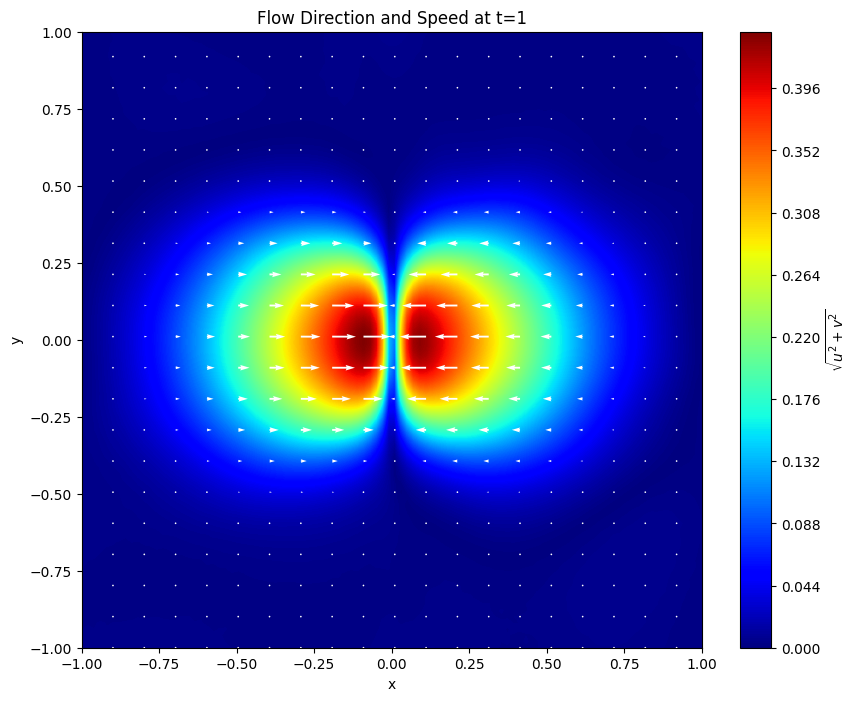

In [51]:
plot_master_velocity(model, 1)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_time_progression(model, n=100, device=torch.device("cuda")):
    model.eval()
    
    t_values = [0.0, 0.3, 0.5, 1.0]
    
    x = torch.linspace(-1, 1, n, device=device)
    y = torch.linspace(-1, 1, n, device=device)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    
    x_test = X.reshape(-1, 1)
    y_test = Y.reshape(-1, 1)

    fig, axes = plt.subplots(2, 4, figsize=(20, 8), dpi=1000, constrained_layout=True)

    for col, t_val in enumerate(t_values):
        
        t_test = torch.full_like(x_test, t_val)
        
        with torch.no_grad():
            uv = model(t_test, x_test, y_test)
            
        u = uv[:, 0].reshape(n, n).cpu().numpy()
        v = uv[:, 1].reshape(n, n).cpu().numpy()

        ax_u = axes[0, col]
        c1 = ax_u.contourf(X.cpu().numpy(), Y.cpu().numpy(), u, levels=100, cmap='viridis')
        ax_u.set_title(f"u(x,y) at t={t_val}")
        ax_u.set_xlabel("x")
        ax_u.set_ylabel("y")
        fig.colorbar(c1, ax=ax_u, shrink=0.8) 

        ax_v = axes[1, col] 
        c2 = ax_v.contourf(X.cpu().numpy(), Y.cpu().numpy(), v, levels=100, cmap='plasma')
        ax_v.set_title(f"v(x,y) at t={t_val}")
        ax_v.set_xlabel("x")
        ax_v.set_ylabel("y")
        fig.colorbar(c2, ax=ax_v, shrink=0.8)

    fig.suptitle("PINN Predictions With Time Progression", fontsize=16, fontweight='semibold')
    
    plt.show()

In [98]:
plot_time_progression(model)